### 라이브러리선언

In [4]:
# 데이터 처리관련 라이브러리
import pandas as pd
import numpy as np

In [3]:
# 머신러닝 모델: tree, knn, ensemble: random_forest, svm: support vector machine
from sklearn import tree, neighbors, ensemble, svm
# 머신러닝 전처리
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

### 데이터 불러오기

In [8]:
datasetUrl = "https://raw.githubusercontent.com/hyokwan/python-lecture/refs/heads/master/dataset/cars.csv"
featuresData = pd.read_csv(datasetUrl)
featuresData.info()

<class 'pandas.DataFrame'>
RangeIndex: 963 entries, 0 to 962
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   age     963 non-null    int64
 1   gender  963 non-null    int64
 2   miles   963 non-null    int64
 3   debt    963 non-null    int64
 4   income  963 non-null    int64
 5   sales   963 non-null    int64
dtypes: int64(6)
memory usage: 45.3 KB


# A. 데이터 전처리

### 1. 데이터 타입통합 및 특성 숫자변환

In [10]:
### Skip (데이터타입 통합은 모든 컬럼에 대해서 정의해줘야 한다)

### 2. 특성선정 및 데이터 분리

In [35]:
# 특성 선정
label = ["sales"]
stdCorr = 0.3
# 상관분석
corrDf = featuresData.corr(numeric_only=True)
features = list( corrDf.loc[ (abs( corrDf.sales) >= stdCorr) &
            (corrDf.sales != 1) ].index)
print(f"정답지: {label} 문제지: {features}")

정답지: ['sales'] 문제지: ['age', 'miles', 'debt', 'income']


In [39]:
# 데이터 분리
trainData, testData = train_test_split( featuresData, test_size=0.2, random_state=5)
trainDataFeatures = trainData.loc[:, features]
trainDataLabel = trainData.loc[:, label]
testDataFeatures = testData.loc[:, features]
testDataLabel = testData.loc[:, label]
print( trainDataFeatures.shape )
print( trainDataLabel.shape )
print( testDataFeatures.shape )
print( testDataLabel.shape )


(770, 4)
(770, 1)
(193, 4)
(193, 1)


# B. 모델 정의

### 3. 모델 정의 및 학습

In [108]:
from sklearn import linear_model 
# DecisionTree 모델
dtModel = tree.DecisionTreeRegressor(random_state=1)
# RandomForest 모델
rfModel = ensemble.RandomForestRegressor(random_state=1, n_estimators=5)
# lrModel = linear_model.LinearRegression()
### 학

In [109]:
# DecisionTree 학습덩어리
fittedDtModel = \
        dtModel.fit(X= trainDataFeatures, y=trainDataLabel)
# RandomForest 학습덩어리
fittedRfModel = \
        rfModel.fit(X= trainDataFeatures, y=trainDataLabel)

c:\Users\hk\fintech_data_2026\.venv\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [110]:
# import matplotlib.pyplot as plt
# from sklearn.tree import plot_tree
# plt.Figure(figsize=(30,8))
# plot_tree(fittedDtModel)
# plt.savefig("tree.png", dpi=300)

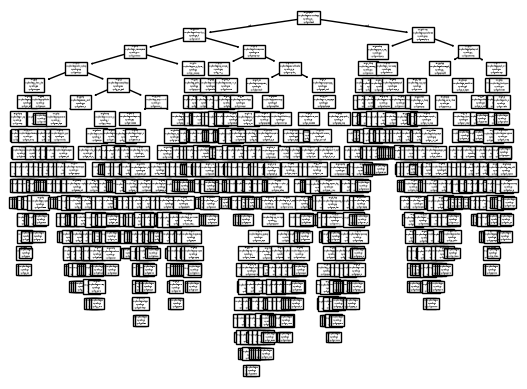

In [111]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.Figure(figsize=(30,8))
plot_tree(fittedRfModel.estimators_[4])
plt.savefig("tree.png", dpi=300)

In [112]:
# import matplotlib.pyplot as plt
# from sklearn.tree import plot_tree
# plt.Figure(figsize=(30,8))
# plot_tree(fittedDtModel)
# plt.savefig("tree.png", dpi=300)

# C. 예측

### 4. 모델 예측

In [113]:
# features

In [114]:
# 화면입력 데이터 기반 예측
inAge = 50
inMiles = 100
indept = 50000
inIncome = 2000
testDf = pd.DataFrame( [[ inAge,inMiles,indept,inIncome      ]])
recommededSales = fittedDtModel.predict( X=testDf )
recommededSales

c:\Users\hk\fintech_data_2026\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([27591.])

In [115]:
testDataLabel.shape

(193, 2)

In [116]:
# 테스트데이터 기반 예측
predictDtValue =  fittedDtModel.predict(X=testDataFeatures)
len(predictDtValue)

193

In [117]:
testDataLabel["PREDCIT_DT"] = predictDtValue
testDataLabel

,sales,PREDCIT_DT
769,1213,650.0
286,3666,673.0
568,1285,4923.0
627,2734,4731.0
33,25394,28134.0
...,...,...
84,6200,3094.0
417,1728,2488.0
775,1058,620.0
288,8404,8520.0


### 5. 데이터 정리

In [148]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error

In [149]:
mean_absolute_error(y_true=testDataLabel.SALES,
                    y_pred=testDataLabel.PREDCIT_DT)

2509.6891191709847

In [150]:
mean_squared_error(y_true=testDataLabel.SALES,
                    y_pred=testDataLabel.PREDCIT_DT)

13995566.777202072

In [151]:
root_mean_squared_error(y_true=testDataLabel.SALES,
                    y_pred=testDataLabel.PREDCIT_DT)

3741.064925552893

In [147]:
# 회귀식에서 정확도:  
# MAE(Mean Absolute Error): 평균절대오차 
# MSE(Mean Squared Error): 평균제곱오차
# RMSE(Root Mean Squared Error): 평균제곱근오차
# MAPE(Mean Absolute Percentage Error): 평균절대 백분율오차
testDataLabel.columns = testDataLabel.columns.str.upper()
testDataLabel
# STEP1: 먼저 오차를 구한다
testDataLabel["DIFF"] = abs( testDataLabel.SALES - testDataLabel.PREDCIT_DT)
maeValue = testDataLabel.DIFF.mean()
testDataLabel["MAE"] = maeValue
testDataLabel["DIFF_SQUARE"] = testDataLabel["DIFF"]**2
mseValue = testDataLabel.DIFF_SQUARE.mean()
testDataLabel["MSE"] = mseValue
testDataLabel
rmseValue = np.sqrt(mseValue)
testDataLabel["RMSE"] = rmseValue
testDataLabel

,SALES,PREDCIT_DT,DIFF,MAE,DIFF_SQUARE,MSE,RMSE
769,1213,650.0,563.0,2509.689119,316969.0,1.399557e+07,3741.064926
286,3666,673.0,2993.0,2509.689119,8958049.0,1.399557e+07,3741.064926
568,1285,4923.0,3638.0,2509.689119,13235044.0,1.399557e+07,3741.064926
627,2734,4731.0,1997.0,2509.689119,3988009.0,1.399557e+07,3741.064926
33,25394,28134.0,2740.0,2509.689119,7507600.0,1.399557e+07,3741.064926
...,...,...,...,...,...,...,...
84,6200,3094.0,3106.0,2509.689119,9647236.0,1.399557e+07,3741.064926
417,1728,2488.0,760.0,2509.689119,577600.0,1.399557e+07,3741.064926
775,1058,620.0,438.0,2509.689119,191844.0,1.399557e+07,3741.064926
288,8404,8520.0,116.0,2509.689119,13456.0,1.399557e+07,3741.064926


In [153]:
# MAPE
testDataLabel


,SALES,PREDCIT_DT,DIFF,MAE,DIFF_SQUARE,MSE,RMSE
769,1213,650.0,563.0,2509.689119,316969.0,1.399557e+07,3741.064926
286,3666,673.0,2993.0,2509.689119,8958049.0,1.399557e+07,3741.064926
568,1285,4923.0,3638.0,2509.689119,13235044.0,1.399557e+07,3741.064926
627,2734,4731.0,1997.0,2509.689119,3988009.0,1.399557e+07,3741.064926
33,25394,28134.0,2740.0,2509.689119,7507600.0,1.399557e+07,3741.064926
...,...,...,...,...,...,...,...
84,6200,3094.0,3106.0,2509.689119,9647236.0,1.399557e+07,3741.064926
417,1728,2488.0,760.0,2509.689119,577600.0,1.399557e+07,3741.064926
775,1058,620.0,438.0,2509.689119,191844.0,1.399557e+07,3741.064926
288,8404,8520.0,116.0,2509.689119,13456.0,1.399557e+07,3741.064926
